## Question 5: V-plot Analysis

This question requires creating a V-plot visualization to analyze protein-DNA binding patterns.

### V-plot Background
- When proteins bind to DNA, they protect regions from nuclease cleavage
- Fragment lengths and positions relative to binding sites form a characteristic V-shaped pattern
- X-axis: Position relative to binding site
- Y-axis: Fragment length
- Z-axis (color): Count of fragments

Processed 280653 unique (X,Y) pairs
X-range: -509 to 509
Y-range: 40 to 500


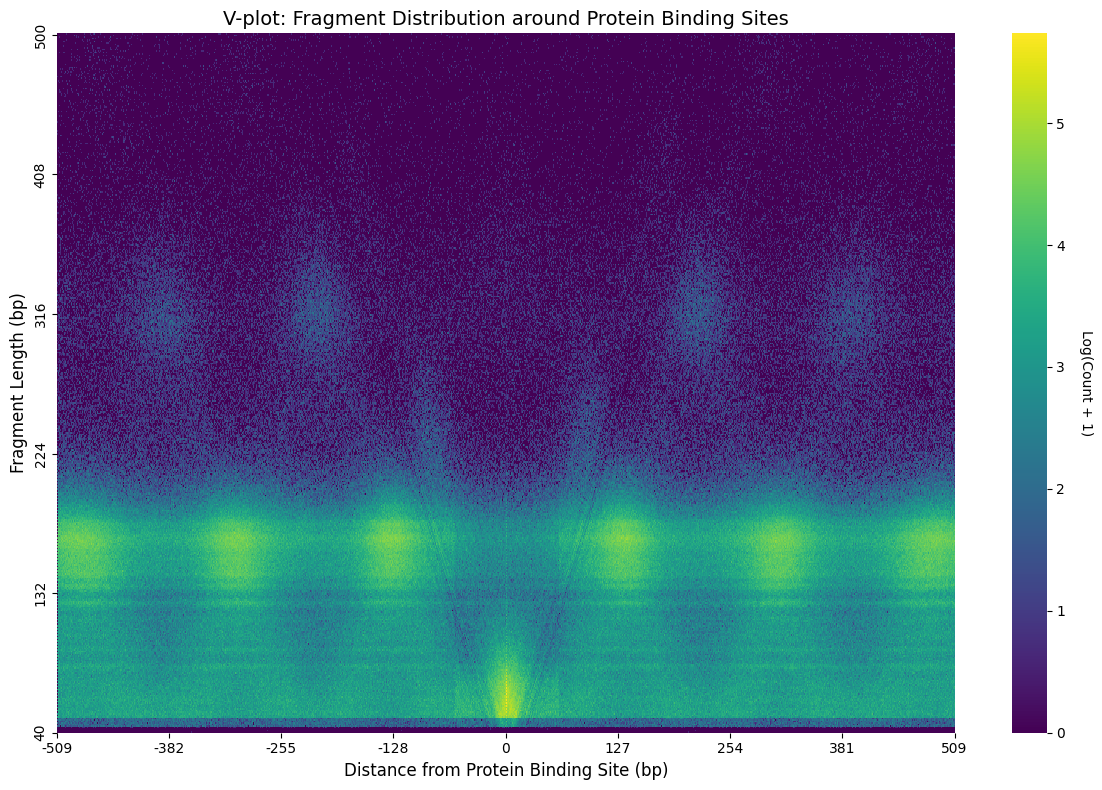

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

def generate_v_plot(input_file, max_x_range=1000, max_y_range=500):
    xy_counts = defaultdict(int)
    
    with open(input_file, 'r') as file:
        for line_num, line in enumerate(file, 1):
            try:
                fields = line.strip().split('\t')
                
                prot_center = (int(fields[2]) + int(fields[3])) / 2
                frag_center = (int(fields[8]) + int(fields[9])) / 2
                
                x_value = int(frag_center - prot_center)
                y_value = int(fields[9]) - int(fields[8])  
                
                if abs(x_value) <= max_x_range and y_value <= max_y_range:
                    xy_counts[(x_value, y_value)] += 1
                    
            except (IndexError, ValueError) as e:
                print(f"Warning: Could not process line {line_num}: {e}")
                continue
    
    unique_x = sorted(set(x for x, _ in xy_counts.keys()))
    unique_y = sorted(set(y for _, y in xy_counts.keys()))
    
    print(f"Processed {len(xy_counts)} unique (X,Y) pairs")
    print(f"X-range: {min(unique_x)} to {max(unique_x)}")
    print(f"Y-range: {min(unique_y)} to {max(unique_y)}")
    
    count_matrix = np.zeros((len(unique_y), len(unique_x)))
    
    for i, y in enumerate(unique_y):
        for j, x in enumerate(unique_x):
            count_matrix[i, j] = xy_counts.get((x, y), 0)
    
    return unique_x, unique_y, count_matrix

try:
    input_file = "mapped.bed"
    x_values, y_values, count_matrix = generate_v_plot(input_file)
    
    plt.figure(figsize=(12, 8))
    
    log_counts = np.log1p(count_matrix)  
    
    ax = sns.heatmap(log_counts, cmap='viridis', xticklabels=500, yticklabels=50)
    
    x_ticks_pos = np.linspace(0, len(x_values)-1, 9).astype(int)
    x_ticks_labels = [x_values[i] for i in x_ticks_pos]
    plt.xticks(x_ticks_pos, x_ticks_labels)
    
    y_ticks_pos = np.linspace(0, len(y_values)-1, 6).astype(int)
    y_ticks_labels = [y_values[i] for i in y_ticks_pos]
    plt.yticks(y_ticks_pos, y_ticks_labels)
    
    plt.xlabel('Distance from Protein Binding Site (bp)', fontsize=12)
    plt.ylabel('Fragment Length (bp)', fontsize=12)
    plt.title('V-plot: Fragment Distribution around Protein Binding Sites', fontsize=14)
    
    plt.gca().invert_yaxis()
    
    cbar = ax.collections[0].colorbar
    cbar.set_label('Log(Count + 1)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print(f"Error: Input file '{input_file}' not found")
except Exception as e:
    print(f"Error during V-plot generation: {str(e)}")